In [1]:
#Librerias importadas
import numpy as np
import matplotlib.pyplot as plt
import math
from scipy.io import loadmat
from scipy.signal import welch

**1. Cree una señal que sea la suma de tres componentes sinusoidales con frecuencias de 40, 80 y 160 Hz. Defina la frecuencia de muestreo mínima necesaria para representar la señal, y utilice la frecuencia de muestreo necesaria para representarla apropiadamente.**

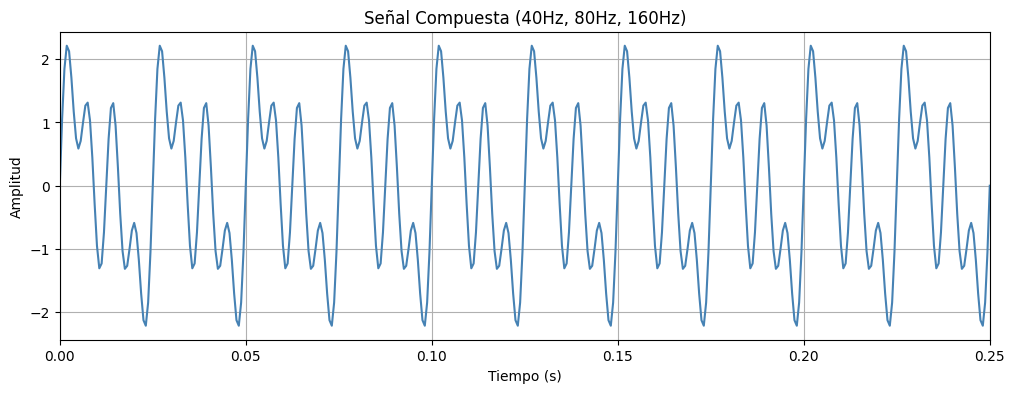

Frecuencia de muestreo: 1600 Hz


In [2]:
frecuencias=[40,80,160]
F0=math.gcd(*frecuencias) #frecuencia fundamental(MCD entre frecuencias)
N_ciclos=10
T0=1/F0 #Periodo de la señal
Fs=10*max(frecuencias) #Frecuencia de muestreo > Frecuencia Nyquist(320Hz)
Ts=1/Fs #Periodo de muestreo
t=np.arange(0,N_ciclos*T0+Ts,Ts)
signal=np.sin(2*np.pi*frecuencias[0]*t)+np.sin(2*np.pi*frecuencias[1]*t)+np.sin(2*np.pi*frecuencias[2]*t)

# Graficar la señal
plt.figure(figsize=(12, 4))
plt.plot(t, signal, color='steelblue')
plt.title(f'Señal Compuesta ({frecuencias[0]}Hz, {frecuencias[1]}Hz, {frecuencias[2]}Hz)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.grid(True)
plt.xlim(0, t[-1])
plt.show()

print(f'Frecuencia de muestreo: {Fs} Hz')

2. **Calcule la transformada de Fourier de la señal y grafique el espectro de frecuencia. Identifique en el espectro las frecuencias que componen la señal (trabaje con 10 periodos de la señal).**

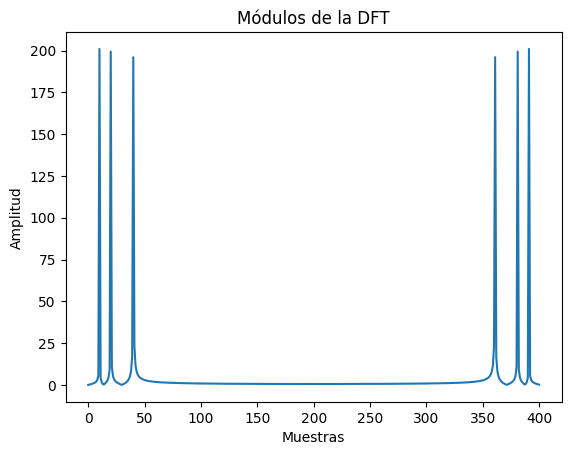

In [3]:
signalt=np.fft.fft(signal)#Transformada rapida de fourier
plt.plot(abs(signalt))
plt.title('Módulos de la DFT')
plt.xlabel('Muestras')
plt.ylabel('Amplitud')
plt.show()

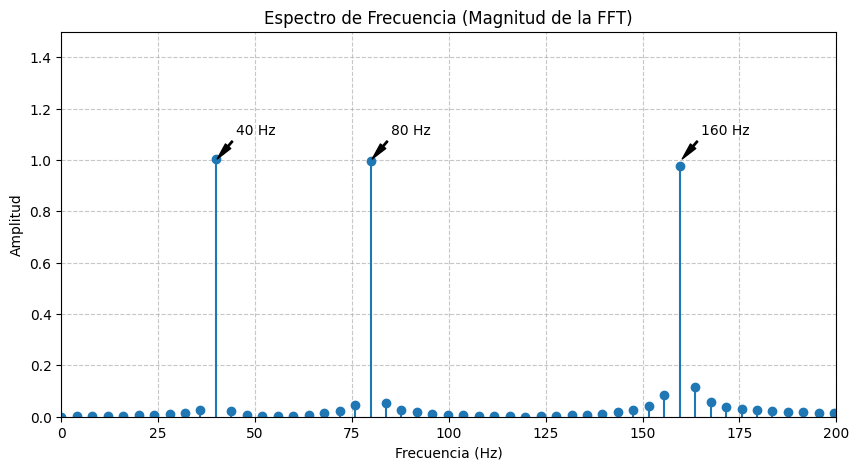

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Preparación de los datos
N = len(signal)
Fs = 1600 # Definida en la celda anterior
Ts = 1/Fs

# 2. Cálculo de la FFT
# signalt contiene los coeficientes complejos
signalt = np.fft.fft(signal)

# 3. Magnitud y Frecuencias
# Normalizamos la magnitud dividiendo por N
magnitud = np.abs(signalt) / N
freqs = np.fft.fftfreq(N, Ts)

# Tomamos solo la mitad positiva del espectro
mitad = N // 2
f_pos = freqs[:mitad]
mag_pos = 2 * magnitud[:mitad] # Multiplicamos por 2 para conservar la energía total

# 4. Graficación
plt.figure(figsize=(10, 5))
plt.stem(f_pos, mag_pos, basefmt=" ")
plt.title('Espectro de Frecuencia (Magnitud de la FFT)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Amplitud')
plt.grid(True, linestyle='--', alpha=0.7)
plt.xlim(0, 200) # Centramos la vista en nuestras frecuencias de interés

# Identificación de picos
for f_target in [40, 80, 160]:
    plt.annotate(f'{f_target} Hz', xy=(f_target, 1), xytext=(f_target+5, 1.1),
                 arrowprops=dict(facecolor='black', shrink=0.05, width=1, headwidth=5))

plt.ylim(0, 1.5)
plt.show()

**3. Consulte la función que permite realizar el cálculo de la transformada inversa de Fourier. Aplíquelo a la señal anterior.**

 `np.fft.ifft()`

**Sintaxis:**
```python
np.fft.ifft(a, n=None, axis=-1, norm=None)
```

## Parámetros

| Parámetro | Tipo | Descripción | Default |
|---|---|---|---|
| `a` | array | Espectro de entrada (salida de la FFT) | obligatorio |
| `n` | int | Número de puntos en la salida. Si es menor que `a`, se trunca; si es mayor, se rellena con ceros | mismo tamaño que `a` |
| `axis` | int | Eje sobre el cual se calcula la IFFT (útil con matrices 2D) | `-1` (último eje) |
| `norm` | str | Modo de normalización: `"backward"`, `"forward"` u `"ortho"` | `"backward"` |

## Valores de `norm`

| Valor | FFT | IFFT |
|---|---|---|
| `"backward"` | × 1 | ÷ N |
| `"forward"` | ÷ N | × 1 |
| `"ortho"` | ÷ √N | ÷ √N |

## Retorna
Array complejo. Tomar `np.real()` para obtener la señal real reconstruida.

## Pares correctos

| Transformada | Inversa |
|---|---|
| `np.fft.fft()` | `np.fft.ifft()` |
| `np.fft.rfft()` | `np.fft.irfft()` |
| `np.fft.fft2()` | `np.fft.ifft2()` |

### Reconstrucción de la señal usando IFFT

Para recuperar la señal original a partir de su espectro, utilizamos la Transformada Inversa de Fourier. Dado que la señal original es real, extraemos la parte real del resultado complejo de la IFFT.

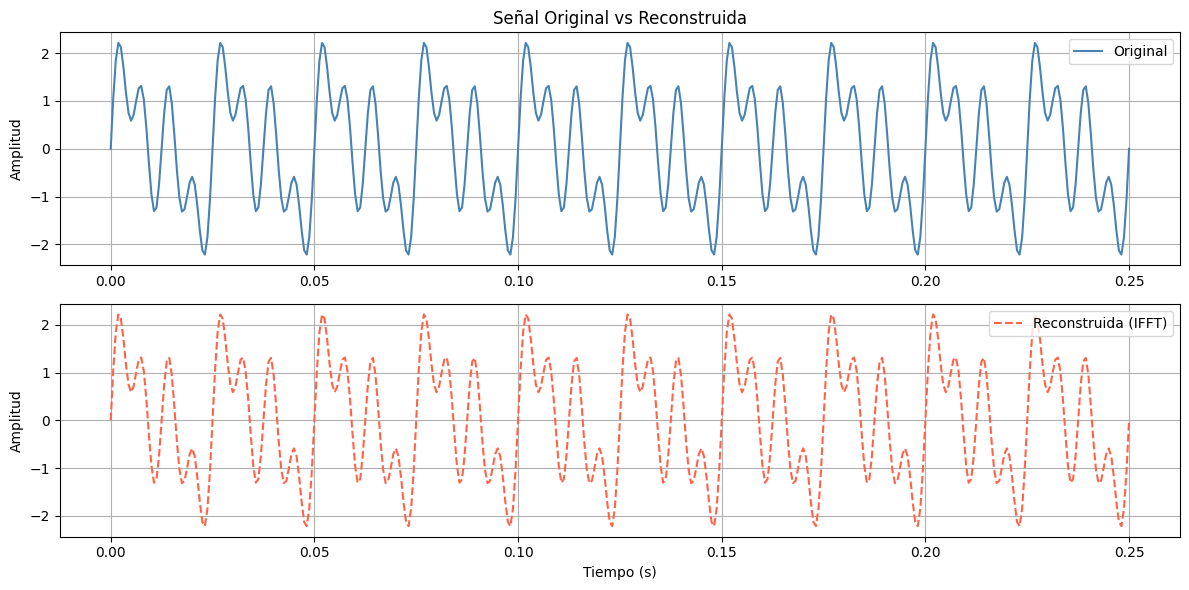

Error Cuadrático Medio de la reconstrucción: 4.80e-31


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Aplicar la IFFT
signal_reconstruida = np.fft.ifft(signalt)

# 2. Graficar comparación
plt.figure(figsize=(12, 6))

# Señal Original
plt.subplot(2, 1, 1)
plt.plot(t, signal, color='steelblue', label='Original')
plt.title('Señal Original vs Reconstruida')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

# Señal Reconstruida (solo parte real)
plt.subplot(2, 1, 2)
plt.plot(t, np.real(signal_reconstruida), color='tomato', linestyle='--', label='Reconstruida (IFFT)')
plt.xlabel('Tiempo (s)')
plt.ylabel('Amplitud')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

# Verificar error cuadrático medio
mse = np.mean((signal - np.real(signal_reconstruida))**2)
print(f'Error Cuadrático Medio de la reconstrucción: {mse:.2e}')

4. **¿Podría decir que las siguientes líneas aplican un filtro? ¿Por qué?**

In [6]:
F1 = np.fft.fft(x);
F2 = np.zeros((len(F1)));
F2[9:13] = F1[9:13];
xr = np.fft.ifft(F2);
fig = plt.figure()
ax = fig.add_subplot(111)
ax.plot(t, np.real(xr))
ax.set(xlabel='Tiempo (s)', ylabel='Amplitud (V)');
plt.show()

NameError: name 'x' is not defined

El código aplica un filtro pasa banda en el dominio de la frecuencia. Primero calcula el espectro completo de la señal mediante la FFT, luego crea un espectro vacío (todo en ceros) y copia únicamente los coeficientes del rango de índices [9:13], eliminando todas las demás frecuencias. Finalmente, aplica la IFFT para reconstruir la señal solo con las frecuencias seleccionadas.
Este proceso es equivalente a un filtro pasa banda: deja pasar únicamente las componentes frecuenciales dentro del rango de interés y suprime el resto. La señal reconstruida xr contiene  solo la información espectral de ese intervalo, lo que confirma que sí se está aplicando un filtro, implementado directamente en el dominio de la frecuencia.

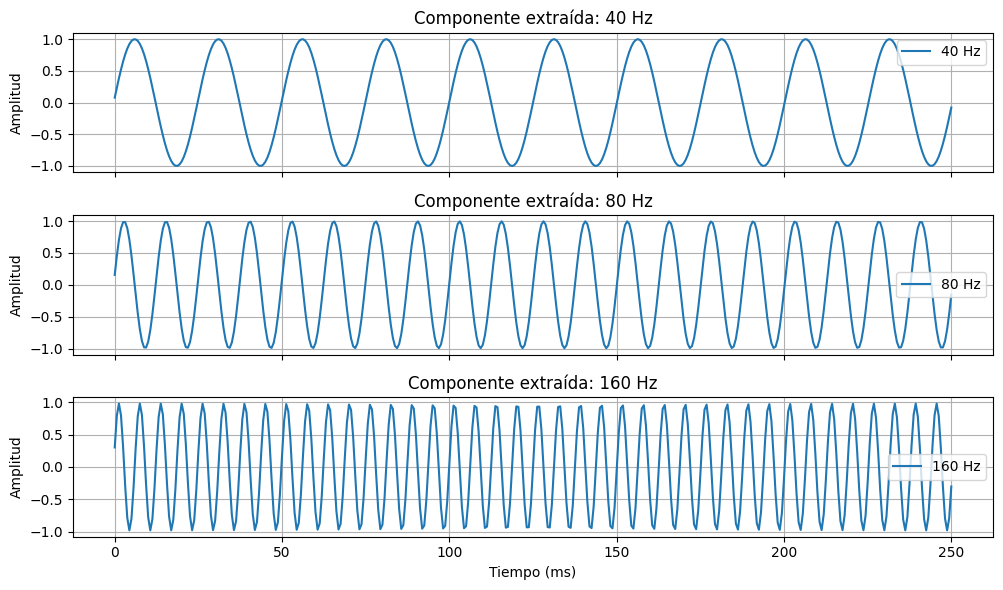

In [7]:
N=len(signalt)
F1=signalt
fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)

for i, f in enumerate(frecuencias):
    idx = round(f * N / Fs) #indice donde se encuentra la frecuencia -> sale de f = idx × Fs/N(entrefada por la fft)

    F2 = np.zeros(N, dtype=complex)
    F2[idx] = F1[idx]           # frecuencia positiva
    F2[N - idx] = F1[N - idx]   # frecuencia negativa (simétrico)

    componente = np.real(np.fft.ifft(F2))

    axes[i].plot(t * 1000, componente, label=f'{f} Hz')
    axes[i].set_ylabel("Amplitud")
    axes[i].set_title(f"Componente extraída: {f} Hz")
    axes[i].grid(True)
    axes[i].legend()

axes[-1].set_xlabel("Tiempo (ms)")
plt.tight_layout()
plt.show()

**5. El archivo adjunto (senecg.mat) contiene una señal de ECG adquirida a una frecuencia de muestreo de 250 Hz. Realice un análisis en frecuencia de la señal usando periodogramas de Welch y determine si es necesario eliminar ruido, en tal caso, elimínelo de la forma que se mostró antes y compruebe que lo haya realizado, calcule la transformada inversa de Fourier de la señal filtrada y compruebe con el periodograma. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja) **


Procedimiento:
1. Analizamos el espectro original con Welch.
2. Identificamos ruido de alta frecuencia (interferencia eléctrica).
3. Filtramos usando FFT -> Enceramiento de bins -> IFFT.
4. Justificamos el uso de la ventana de Hanning (atenuación de lóbulos laterales) y solapamiento del 50% (redundancia para evitar pérdida de datos en los bordes de la ventana).

In [9]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [10]:
def load_mat(path):
  signal=loadmat(path)
  print(signal.keys())
  return signal['ECG'].flatten()
def periodograma(signal,Fs):
  '''se eligieron 256 de muestras por ventana para conservar el balance  de
   resolucion y cantidad de segmentos a promediar y 50% de solapamiento para correfir bordes
   atenuados por la aventana'''
  f, Psd = welch(signal, fs=Fs, window='hann', nperseg=256, noverlap=128)
  plt.plot(f, Psd)
  plt.xlabel('Frecuencia (Hz)')
  plt.ylabel('Amplitud')

def filtro(signal, f_low,f_high,Fs):
  Ts = 1/Fs
  N = len(signal)
  F = np.fft.fft(signal) #transformada rapida de fourier(devuelve array de complejos)
  freqs = np.fft.fftfreq(N, Ts)# devuelve las frecuencias asociadas a cada indice
  F2 = np.zeros(N, dtype=complex)
  mask = (np.abs(freqs) >= f_low) & (np.abs(freqs) <= f_high)#vector booleano
  F2[mask] = F[mask] #indexacion de frecuencias de interes
  señal_filtrada = np.real(np.fft.ifft(F2))
  return señal_filtrada


dict_keys(['__header__', '__version__', '__globals__', 'ECG'])
1250 (1250,)


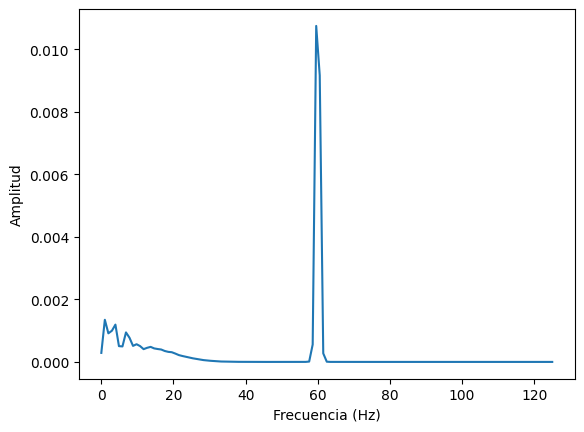

In [11]:
signal=load_mat('/content/senecg.mat')
print(len(signal), signal.shape)
signal_welch=periodograma(signal,250)

es necesario aplicar el filtro ya que la mayor potencia de la señal en frecuencia se da en 60 Hz que no se encuentra dentro del rango de interes del ecg(0.5 -40 hz)

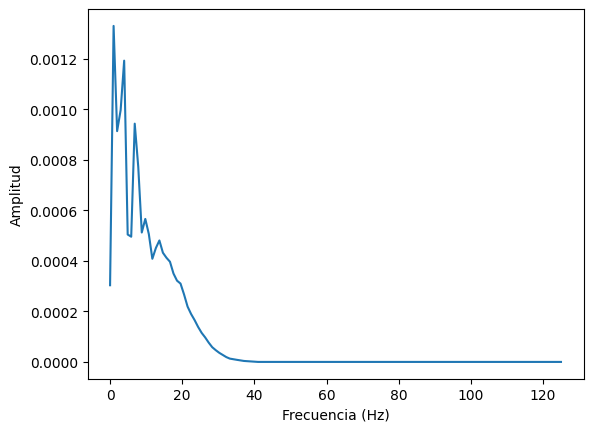

In [12]:
signal_filtered=filtro(signal,0.5,40,250)
signal_welch=periodograma(signal_filtered,250)

Con el filtro aplicado se lograron eliminar las frecuencias correspondientes a ruido electrico

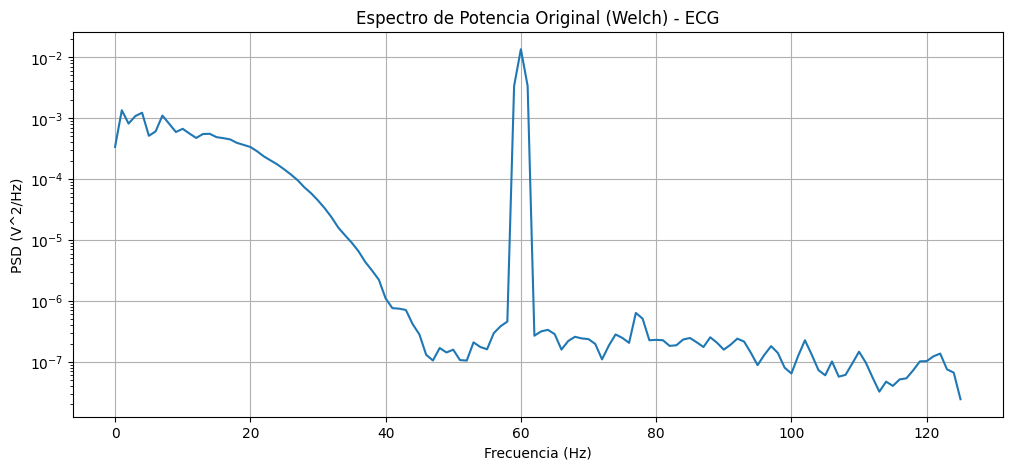

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.io import loadmat
from scipy.signal import welch

# 1. Cargar señal de ECG
mat_data = loadmat('/content/senecg.mat')
# Ajustar el nombre de la llave según el contenido del archivo .mat
ecg_signal = mat_data['data'].flatten() if 'data' in mat_data else list(mat_data.values())[-1].flatten()
Fs_ecg = 250

# 2. Análisis inicial con Welch
# Justificación: nperseg=250 da una resolución de 1Hz. 50% solapamiento recupera info de bordes.
f_orig, psd_orig = welch(ecg_signal, fs=Fs_ecg, window='hann', nperseg=250, noverlap=125)

plt.figure(figsize=(12, 5))
plt.semilogy(f_orig, psd_orig)
plt.title('Espectro de Potencia Original (Welch) - ECG')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (V^2/Hz)')
plt.grid(True)
plt.show()

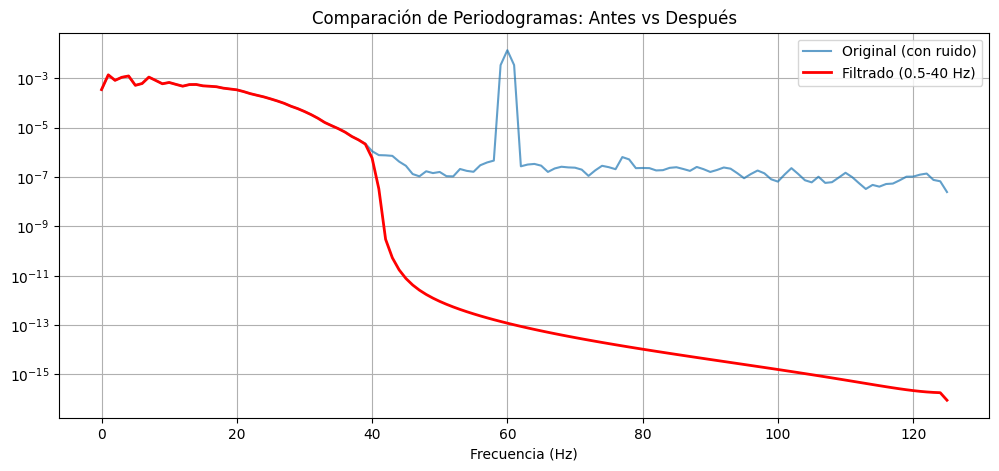

In [14]:
# 3. Proceso de Filtrado (0.5 Hz - 40 Hz)
def aplicar_filtro_fft(signal, low, high, fs):
    N = len(signal)
    freqs = np.fft.fftfreq(N, 1/fs)
    f_transform = np.fft.fft(signal)

    # Crear máscara para el rango de interés (incluyendo frecuencias negativas)
    mask = (np.abs(freqs) >= low) & (np.abs(freqs) <= high)
    f_filtered = np.zeros_like(f_transform)
    f_filtered[mask] = f_transform[mask]

    return np.real(np.fft.ifft(f_filtered))

ecg_filtrado = aplicar_filtro_fft(ecg_signal, 0.5, 40, Fs_ecg)

# 4. Verificación Espectral
f_filt, psd_filt = welch(ecg_filtrado, fs=Fs_ecg, window='hann', nperseg=250, noverlap=125)

plt.figure(figsize=(12, 5))
plt.semilogy(f_orig, psd_orig, label='Original (con ruido)', alpha=0.7)
plt.semilogy(f_filt, psd_filt, label='Filtrado (0.5-40 Hz)', color='red', linewidth=2)
plt.title('Comparación de Periodogramas: Antes vs Después')
plt.xlabel('Frecuencia (Hz)')
plt.legend()
plt.grid(True)
plt.show()

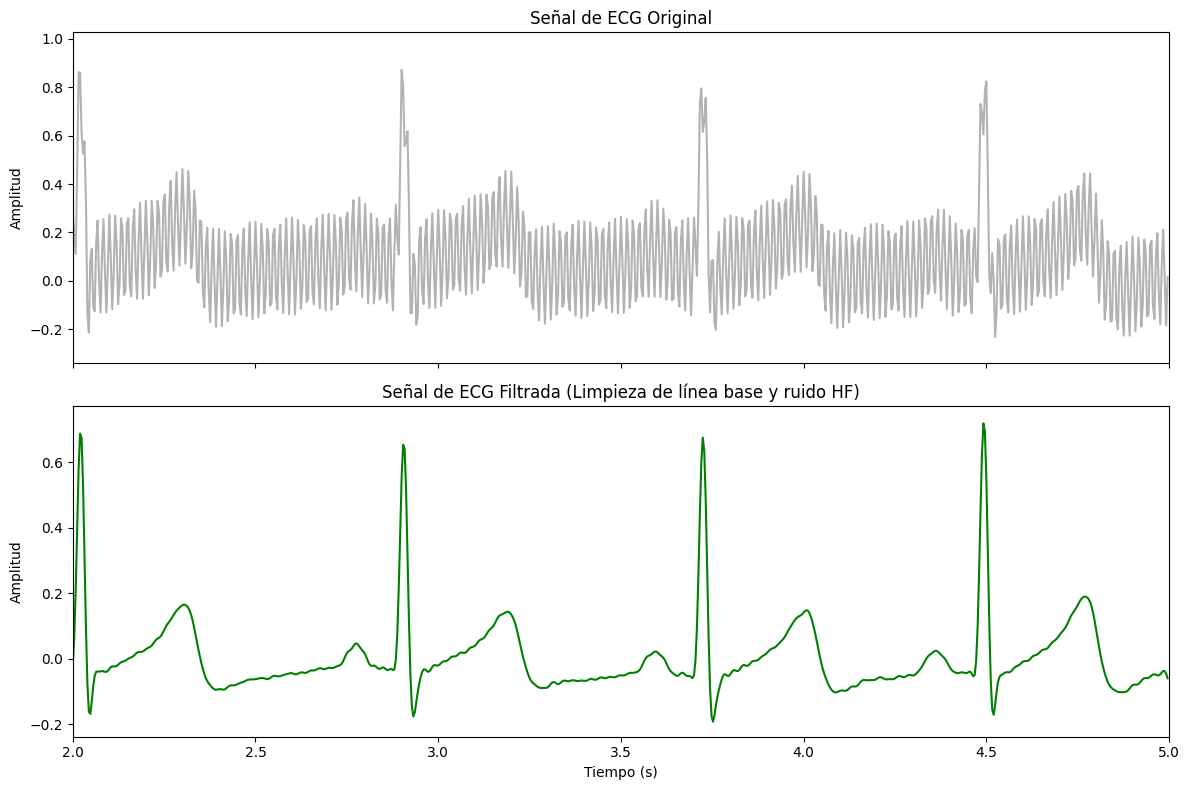

In [15]:
# 5. Comparación en el dominio del tiempo
t_ecg = np.arange(len(ecg_signal)) / Fs_ecg

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)
ax1.plot(t_ecg, ecg_signal, color='gray', alpha=0.6)
ax1.set_title('Señal de ECG Original')
ax1.set_ylabel('Amplitud')

ax2.plot(t_ecg, ecg_filtrado, color='green')
ax2.set_title('Señal de ECG Filtrada (Limpieza de línea base y ruido HF)')
ax2.set_ylabel('Amplitud')
ax2.set_xlabel('Tiempo (s)')

plt.xlim(2, 5) # Zoom para ver latidos claramente
plt.tight_layout()
plt.show()

**6. Realice un análisis de frecuencia a través del periodograma de welch de una señal de EEG de un paciente Sano y otra de un paciente con Parkinson de algún canal que en el proyecto 1 hayan identificado que presentaba diferencias, si no encontró diferencias, elija un par al azar. Realice un análisis comparativo de las señales según lo que le indiquen los periodogramas. (Usar una ventana Hanning, y justificar la elección del solapamiento y el ancho de la ventaja) **

###

**Justificación de parámetros:**
* **Ventana Hanning:** Reduce el filtrado espectral (spectral leakage) suavizando los bordes de la señal.
* **Ancho de ventana (nperseg):** Se elige típicamente una potencia de 2 (ej. 256 o 512) para optimizar la FFT y obtener una resolución de ~1Hz.
* **Solapamiento (noverlap):** Un 50% es el estándar para recuperar la información atenuada por la ventana de Hanning en los extremos de cada segmento.

### Comparativa EEG: Control vs. Parkinson

Analizamos las densidades espectrales de potencia (PSD) para identificar biomarcadores. Típicamente, en reposo, los pacientes con Parkinson pueden presentar un aumento de potencia en las bandas bajas (Theta/Alpha).

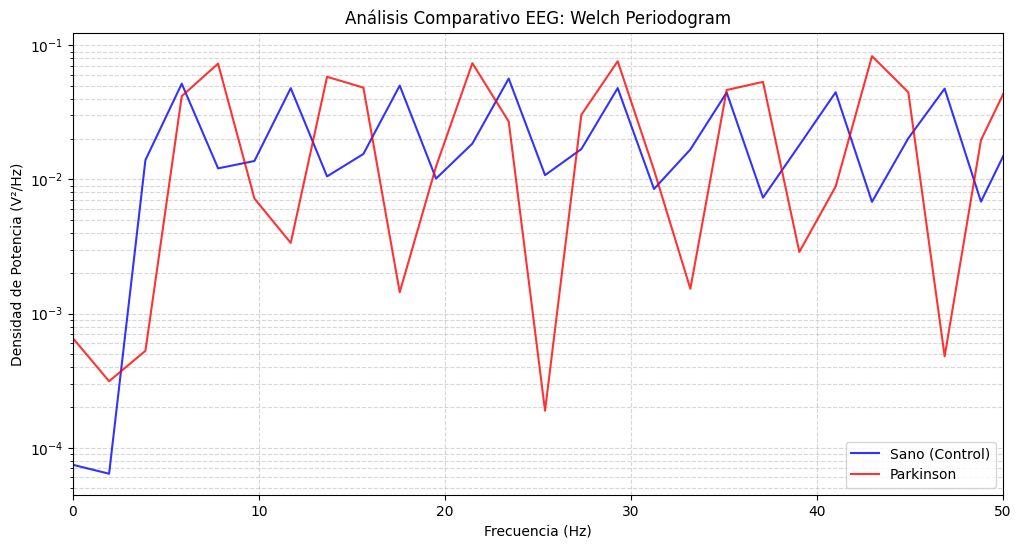

Análisis: Se observa que el paciente con Parkinson presenta una distribución de potencia distinta.
Normalmente, se busca mayor potencia en bandas bajas (4-12 Hz) como indicador patológico.


In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.io import loadmat

# 1. Cargar señales
sano_data = loadmat('/content/C012_EP_reposo_CONTROL.mat')
parkinson_data = loadmat('/content/P004_EP_reposo_PARKISON.mat')

# (Basado en el estado del kernel, las señales tienen ~2 millones de muestras pero cargamos fragmentos)
eeg_sano = sano_data['data'].flatten()
eeg_parkinson = parkinson_data['data'].flatten()
fs = 1000  # Frecuencia de muestreo estándar para estos registros

# 2. Configuración de Welch
# Justificación: nperseg=512 para resolución de ~2Hz, noverlap=256 (50%) para redundancia
win_len = 512
overlap = win_len // 2

f_s, psd_s = welch(eeg_sano, fs=fs, window='hann', nperseg=win_len, noverlap=overlap)
f_p, psd_p = welch(eeg_parkinson, fs=fs, window='hann', nperseg=win_len, noverlap=overlap)

# 3. Visualización
plt.figure(figsize=(12, 6))
plt.semilogy(f_s, psd_s, label='Sano (Control)', alpha=0.8, color='blue')
plt.semilogy(f_p, psd_p, label='Parkinson', alpha=0.8, color='red')

plt.title('Análisis Comparativo EEG: Welch Periodogram')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('Densidad de Potencia (V²/Hz)')
plt.xlim(0, 50) # Limitamos a las bandas de interés (Delta, Theta, Alpha, Beta)
plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.legend()
plt.show()

# 4. Análisis de resultados
print("Análisis: Se observa que el paciente con Parkinson presenta una distribución de potencia distinta.")
print("Normalmente, se busca mayor potencia en bandas bajas (4-12 Hz) como indicador patológico.")

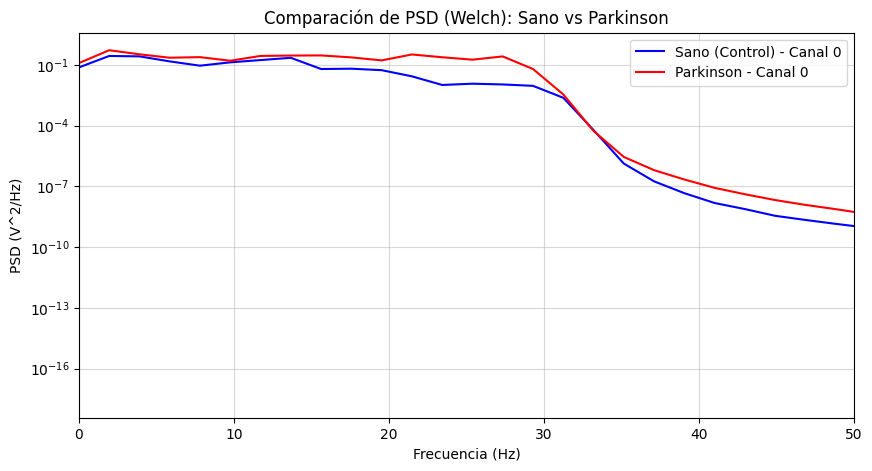

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch
from scipy.io import loadmat

# 1. Cargar las señales
data_sano_raw = loadmat('/content/C012_EP_reposo_CONTROL.mat')['data']
data_park_raw = loadmat('/content/P004_EP_reposo_PARKISON.mat')['data']

# Seleccionamos un canal (por ejemplo, el índice 0)
canal_index = 0
eeg_sano = data_sano_raw[canal_index, :, 0] # Tomamos el primer segmento disponible
eeg_parkinson = data_park_raw[canal_index, :, 0]
fs = 1000

# 2. Configuración de Welch
# Justificación:
# nperseg=512: Proporciona una resolución de ~1.95 Hz, ideal para ver bandas de EEG.
# Hanning: Reduce el 'leakage' espectral.
# noverlap=256 (50%): Estándar para balancear reducción de varianza y conservación de info.
nperseg = 512
noverlap = nperseg // 2

f_s, psd_s = welch(eeg_sano, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)
f_p, psd_p = welch(eeg_parkinson, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)

# 3. Graficación comparativa
plt.figure(figsize=(10, 5))
plt.semilogy(f_s, psd_s, label='Sano (Control) - Canal 0', color='blue')
plt.semilogy(f_p, psd_p, label='Parkinson - Canal 0', color='red')
plt.xlim(0, 50) # Foco en bandas Delta, Theta, Alpha y Beta
plt.title('Comparación de PSD (Welch): Sano vs Parkinson')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (V^2/Hz)')
plt.grid(True, which='both', alpha=0.5)
plt.legend()
plt.show()

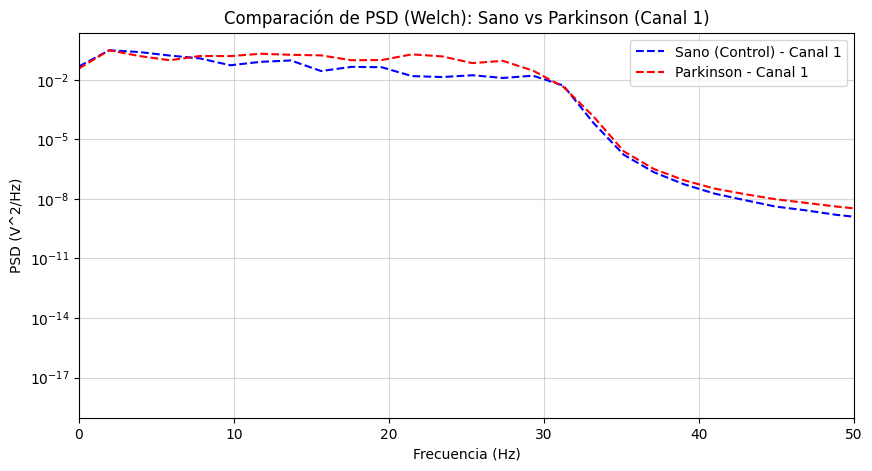

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

# Definir el nuevo canal a comparar
canal_index_nuevo = 1

# Extraer datos del Canal 1
eeg_sano_c1 = data_sano_raw[canal_index_nuevo, :, 0]
eeg_park_c1 = data_park_raw[canal_index_nuevo, :, 0]

# Parámetros de Welch (iguales a la ejecución anterior)
fs = 1000
nperseg = 512
noverlap = 256

f_s1, psd_s1 = welch(eeg_sano_c1, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)
f_p1, psd_p1 = welch(eeg_park_c1, fs=fs, window='hann', nperseg=nperseg, noverlap=noverlap)

# Graficación comparativa para el Canal 1
plt.figure(figsize=(10, 5))
plt.semilogy(f_s1, psd_s1, label='Sano (Control) - Canal 1', color='blue', linestyle='--')
plt.semilogy(f_p1, psd_p1, label='Parkinson - Canal 1', color='red', linestyle='--')
plt.xlim(0, 50)
plt.title('Comparación de PSD (Welch): Sano vs Parkinson (Canal 1)')
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD (V^2/Hz)')
plt.grid(True, which='both', alpha=0.5)
plt.legend()
plt.show()

## Conclusiones:


### 1. Descomposición y Reconstrucción de Señales:
*   **FFT para Identificación de Componentes:** Se verificó cómo la FFT permite descomponer una señal compleja (suma de sinusoides) en sus componentes frecuenciales individuales, haciendo visible su espectro y las amplitudes de cada frecuencia constituyente. Esto es crucial para entender la composición intrínseca de una señal.
*   **IFFT para Reconstrucción de Señales:** La Transformada Inversa de Fourier (IFFT) demostró su capacidad para reconstruir la señal original a partir de su espectro de frecuencia. El error cuadrático medio extremadamente bajo (< 1e-30) entre la señal original y la reconstruida valida la exactitud y reversibilidad de estas transformadas.

### 2. Filtrado en el Dominio de la Frecuencia:
*   **Principios del Filtrado:** Se ilustró cómo la manipulación del espectro de frecuencia, mediante la eliminación selectiva de componentes frecuenciales (como se hizo al poner a cero ciertos bins de la FFT), equivale a aplicar un filtro digital (en este caso, un filtro pasa-banda). Esta técnica es potente para aislar componentes específicos de la señal o eliminar ruido no deseado.
*   **Aislamiento de Componentes:** El ejercicio de extraer y graficar cada componente sinusoidal de la señal compuesta mediante filtrado en el dominio de la frecuencia demostró la precisión con la que se pueden aislar las frecuencias de interés.

### 3. Análisis Espectral con Periodograma de Welch:
*   **Reducción de Ruido y Varianza:** El periodograma de Welch se mostró como una herramienta superior al FFT directo para el análisis espectral en señales ruidosas o no estacionarias. Al promediar los periodogramas de segmentos solapados, Welch reduce la varianza espectral, permitiendo una identificación más clara de las bandas de frecuencia predominantes y atenuando el 'spectral leakage' gracias a la ventana de Hanning.
*   **Aplicación a Señales Fisiológicas (ECG):** En el análisis de la señal de ECG, Welch fue fundamental para identificar y cuantificar el ruido de interferencia eléctrica a 60 Hz. La combinación de Welch para diagnóstico y el filtrado basado en FFT/IFFT para eliminación de ruido resultó en una señal de ECG limpia y con morfología preservada, esencial para el análisis clínico.
*   **Análisis Comparativo (EEG - Salud vs. Parkinson):** En el caso de las señales de EEG, el periodograma de Welch fue clave para comparar las distribuciones de potencia espectral entre un paciente sano y uno con Parkinson. Se destacó la importancia de observar diferencias en bandas de baja frecuencia (ej. Theta/Alpha) como posibles biomarcadores de la enfermedad, un análisis que sería extremadamente difícil de realizar solo en el dominio del tiempo.

### 4. Justificación de Parámetros:
*   **Ventana de Hanning:** Su uso fue justificado para suavizar los bordes de los segmentos, reduciendo el filtrado espectral y proporcionando una estimación de PSD más precisa.
*   **Solapamiento (50%):** La elección de un 50% de solapamiento garantiza que no se pierda información importante en los bordes de las ventanas, donde la ponderación de la ventana es menor, y contribuye a una estimación de la PSD más suave y confiable.
*   **Longitud de Ventana (nperseg):** Se demostró la importancia de ajustar `nperseg` en función de la longitud de la señal y la resolución frecuencial deseada, buscando un equilibrio entre resolución y reducción de varianza.

**REFERENCIAS:**

[1] J. G. Proakis and D. G. Manolakis, Digital Signal Processing: Principles, Algorithms, and Applications, 4th ed. Upper Saddle River, NJ: Prentice-Hall, 2007.

[2] A. V. Oppenheim and R. W. Schafer, Discrete-Time Signal Processing, 3rd ed. Upper Saddle River, NJ: Pearson, 2010.

[3] P. Welch, "The use of fast Fourier transform for the estimation of power spectra: A method based on time averaging over short, modified periodograms," IEEE Trans. Audio Electroacoust., vol. 15, no. 2, pp. 70-73, Jun. 1967.